**Тема:** Распознавание музыкальных инструментов на фото

Датасет: https://www.kaggle.com/datasets/nikolasgegenava/music-instruments

In [1]:
!pip install torchvision torchmetrics >> None

In [2]:
import kagglehub
import pandas as pd
import numpy as np

import torch as th
import torchvision.models as models
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import random_split, DataLoader, Subset
import torch.nn as nn
import torch.optim as optim
import torchmetrics as M
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm import tqdm

from warnings import simplefilter
simplefilter(action='ignore', category=UserWarning)

# Загрузка датасета и pretrained-модели

In [3]:
path = kagglehub.dataset_download('nikolasgegenava/music-instruments')
print('Path to dataset files:', path)

Using Colab cache for faster access to the 'music-instruments' dataset.
Path to dataset files: /kaggle/input/music-instruments


In [4]:
pd.read_csv('/kaggle/input/music-instruments/music_instruments/dataset_stats.csv')

,class,image_count,avg_width,avg_height,min_width,min_height,max_width,max_height,formats,corrupt_files
0,drum,197,145,127,87,60,162,140,"jpeg, png",0
1,violin,196,136,125,42,47,162,140,"jpeg, png",0
2,sitar,195,135,123,46,43,162,140,"jpeg, png",0
3,banjo,194,131,128,51,52,162,140,"jpeg, png",0
4,guitar,194,138,124,56,49,162,140,"jpeg, png",0
5,tabla,193,150,119,87,70,162,140,"jpeg, png",0
6,harmonica,193,147,122,72,43,162,140,"jpeg, png",0
7,accordion,189,150,123,71,60,162,140,"jpeg, png",0
8,flute,189,150,117,60,47,162,140,"jpeg, png",0
9,saxophone,174,132,128,62,45,162,140,"jpeg, png",0


In [5]:
weights = models.ResNet50_Weights.DEFAULT
cnn = models.resnet50(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 91.8MB/s]


In [6]:
cnn

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [7]:
cnn.fc

Linear(in_features=2048, out_features=1000, bias=True)

In [8]:
#for p in cnn.parameters():
#    if p.requires_grad == True:
#        p.requires_grad_(False)

In [9]:
cnn.fc = nn.Linear(in_features=2048, out_features=10)

In [10]:
models.ResNet50_Weights.DEFAULT.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [11]:
transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225))
])

root = '/kaggle/input/music-instruments/music_instruments'
orig_dataset = torchvision.datasets.ImageFolder(root=root, transform=None)
dataset = torchvision.datasets.ImageFolder(root=root, transform=transform)
class_names = dataset.classes

targets = dataset.targets
train_idx, test_idx = train_test_split(
    range(len(dataset)),
    test_size=0.1,
    stratify=targets,
    random_state=42)
train = Subset(dataset, train_idx)
test = Subset(dataset, test_idx)

print(f'Картинок в датасете: {len(dataset)}')
print(f'Количество классов: {len(dataset.classes)}')
print(f'Размер картинки: {dataset[0][0].shape}')

Картинок в датасете: 1806
Количество классов: 10
Размер картинки: torch.Size([3, 128, 128])


# Обучение модели

In [12]:
num_epochs = 20
batch_size = 32
lr = 0.001

In [13]:
loader = DataLoader(train, batch_size=batch_size, shuffle=True)
loader_test = DataLoader(test, batch_size=batch_size)

model = cnn.to('cuda')
criterion = nn.CrossEntropyLoss().to('cuda')
optimizer = optim.AdamW(model.parameters(), lr=lr)

best_acc = 0.0
accuracy = M.Accuracy(task='multiclass', num_classes=10).to('cuda')

epoch_losses = []
accuracy_train = []
accuracy_test = []

for epoch in range(num_epochs):
    model.train()
    accuracy.reset()
    epoch_loss = 0
    for X_batch, y_batch in tqdm(loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
        X_batch = X_batch.to('cuda')
        y_batch = y_batch.to('cuda')
        # forward pass
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        epoch_loss += loss.item()
        accuracy.update(y_pred, y_batch)
        # backprop
        loss.backward()
        # gradient descend
        optimizer.step()
        optimizer.zero_grad()
    epoch_loss = epoch_loss / len(loader)
    epoch_losses.append(epoch_loss)
    accuracy_train.append(accuracy.compute().item())

    model.eval()
    accuracy.reset()
    with th.no_grad():
        for X_batch, y_batch in loader_test:
            X_batch = X_batch.to('cuda')
            y_batch = y_batch.to('cuda')
            y_pred = model(X_batch)
            accuracy.update(y_pred, y_batch)
        accuracy_test.append(accuracy.compute().item())

    print(f'Epoch {epoch+1}: train_loss={epoch_loss:.3f}, acc_train={accuracy_train[-1]:.3f}, acc_test={accuracy_test[-1]:.3f}')

    acc_test = accuracy_test[-1]
    if acc_test > best_acc:
        best_acc = acc_test
        best_state = model.state_dict()

model.load_state_dict(best_state)

Epoch 1/20: 100%|██████████| 51/51 [00:08<00:00,  6.25it/s]


Epoch 1: train_loss=0.858, acc_train=0.764, acc_test=0.834


Epoch 2/20: 100%|██████████| 51/51 [00:05<00:00,  9.31it/s]


Epoch 2: train_loss=0.427, acc_train=0.876, acc_test=0.834


Epoch 3/20: 100%|██████████| 51/51 [00:05<00:00,  9.33it/s]


...

Epoch 19/20: 100%|██████████| 51/51 [00:05<00:00,  9.19it/s]


Epoch 19: train_loss=0.053, acc_train=0.986, acc_test=0.840


Epoch 20/20: 100%|██████████| 51/51 [00:05<00:00,  9.08it/s]


Epoch 20: train_loss=0.043, acc_train=0.987, acc_test=0.856


<All keys matched successfully>

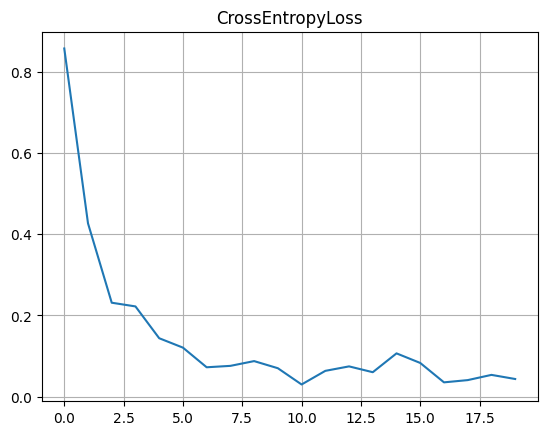

In [14]:
plt.title('CrossEntropyLoss')
plt.plot(epoch_losses)
plt.grid(True)
plt.show()

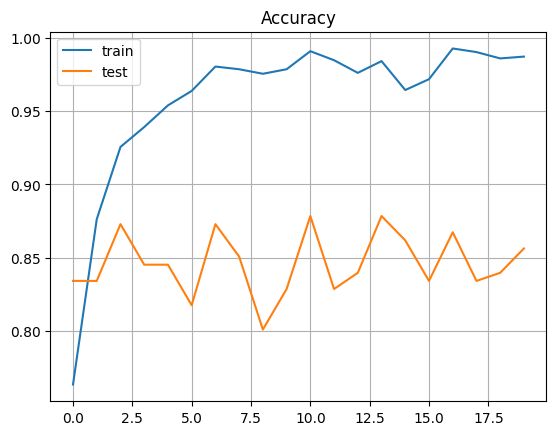

In [15]:
plt.title('Accuracy')
plt.plot(accuracy_train, label='train')
plt.plot(accuracy_test, label='test')
plt.grid(True)
plt.legend()
plt.show()

# Тестирование лучшей модели

In [16]:
def compute_metrics(model, dataloader):
    model.eval()
    all_preds = []
    all_targets = []

    with th.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to('cuda')
            y_batch = y_batch.to('cuda')

            logits = model(X_batch)
            preds = th.argmax(logits, dim=1)

            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    y_pred = th.cat(all_preds).numpy()
    y_true = th.cat(all_targets).numpy()

    report = classification_report(y_true, y_pred, target_names=class_names)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', xticks_rotation=45)
    fig = disp.figure_
    plt.close(fig)

    return {'prf_report': report,
            'conf_matrix': fig,
            'predictions': y_pred,
            'targets': y_true}

In [17]:
metrics_best_model = compute_metrics(model, loader_test)
print(metrics_best_model['prf_report'])

              precision    recall  f1-score   support

   accordion       0.94      0.89      0.92        19
       banjo       1.00      0.79      0.88        19
        drum       0.89      0.84      0.86        19
       flute       0.86      1.00      0.92        18
      guitar       0.74      0.89      0.81        19
   harmonica       0.94      1.00      0.97        17
   saxophone       1.00      0.69      0.81        16
       sitar       0.76      0.84      0.80        19
       tabla       0.76      0.94      0.84        17
      violin       0.80      0.67      0.73        18

    accuracy                           0.86       181
   macro avg       0.87      0.86      0.86       181
weighted avg       0.87      0.86      0.86       181



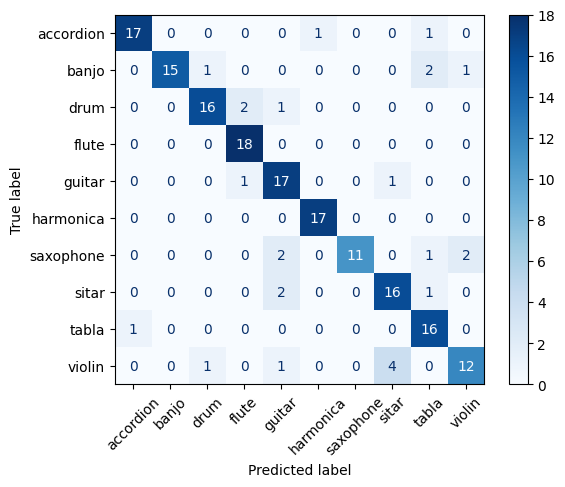

In [18]:
metrics_best_model['conf_matrix']

In [19]:
y_true = metrics_best_model['targets']
y_pred = metrics_best_model['predictions']

errors = np.where(y_pred != y_true)[0]
errors

array([  5,  10,  13,  18,  27,  45,  49,  51,  55,  65,  70,  76,  88,
        89,  96, 107, 110, 111, 125, 126, 144, 149, 154, 167, 174, 175])

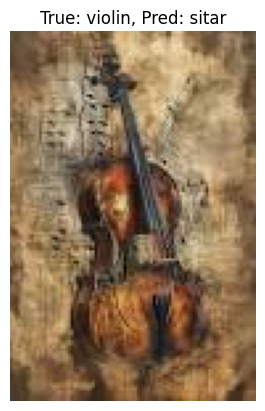

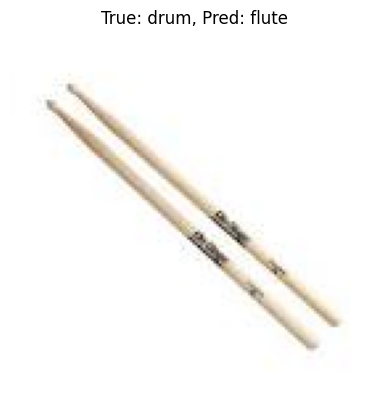

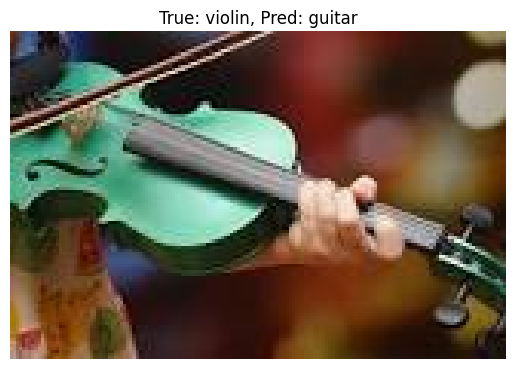

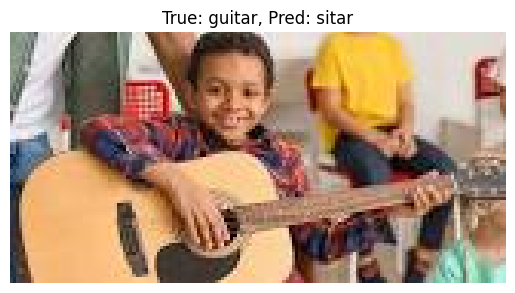

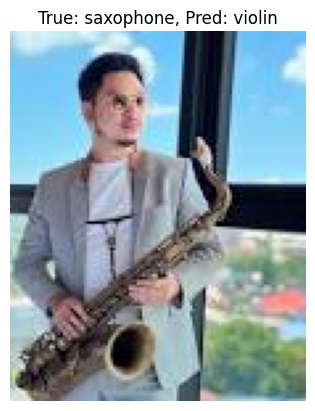

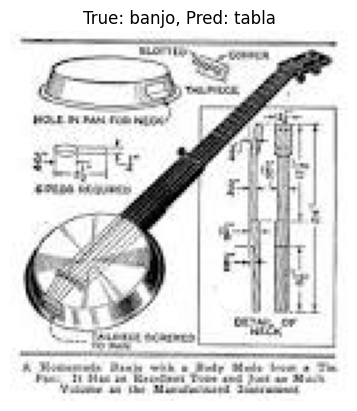

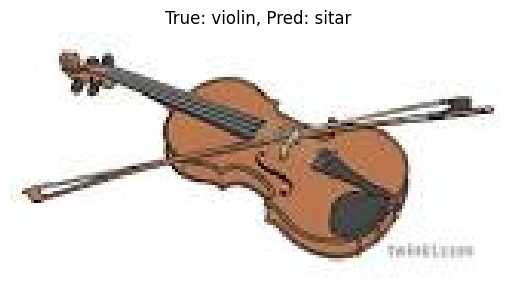

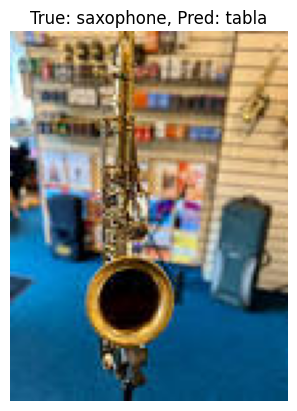

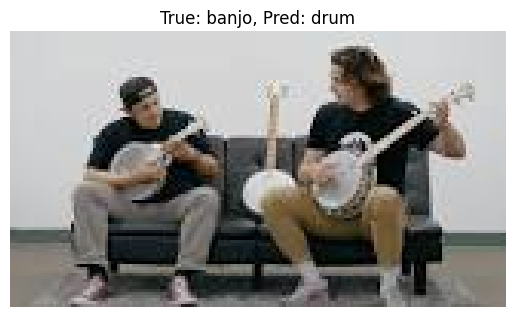

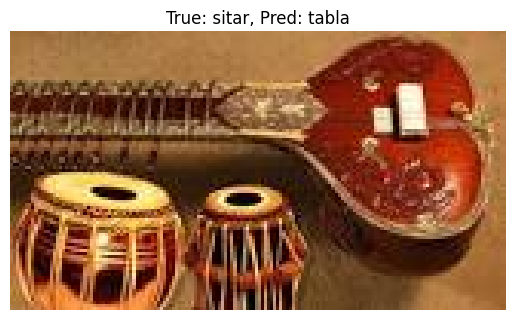

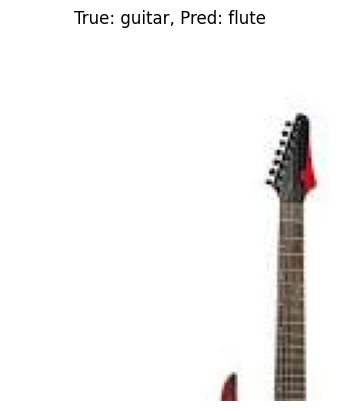

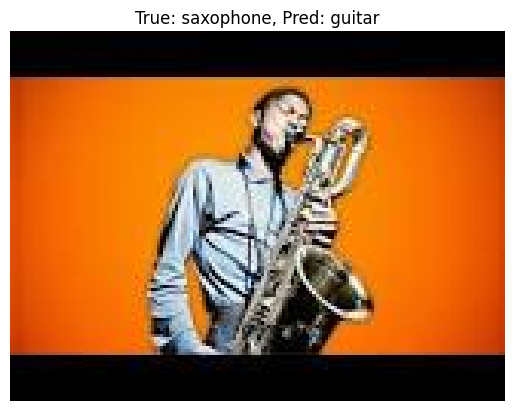

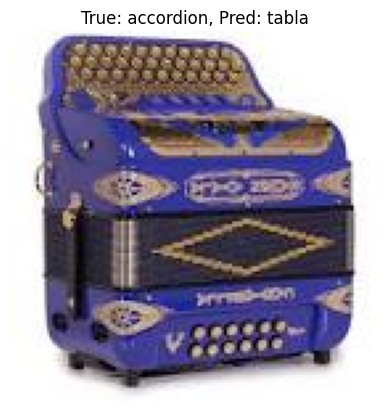

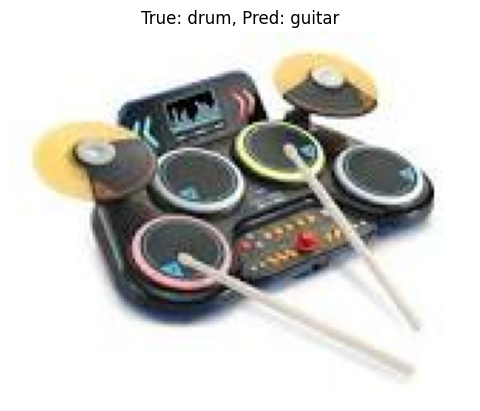

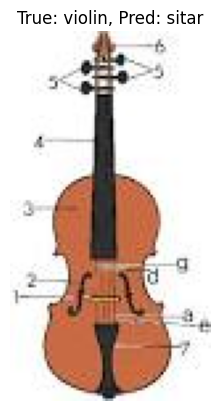

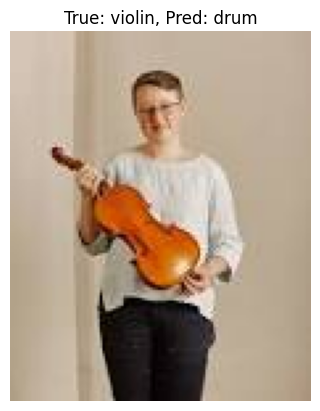

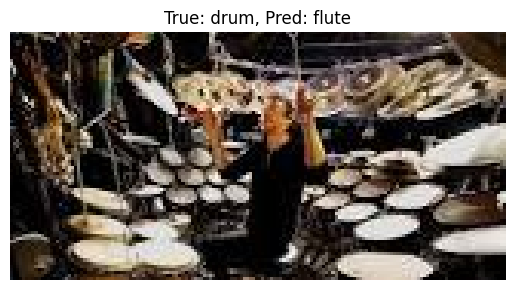

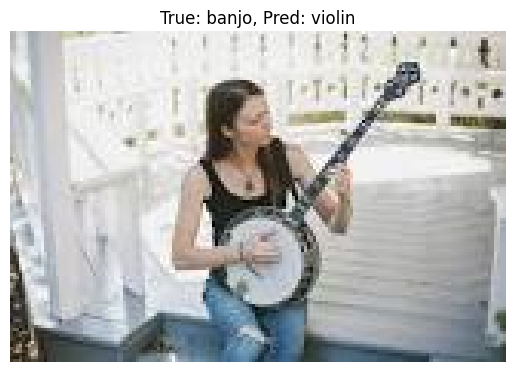

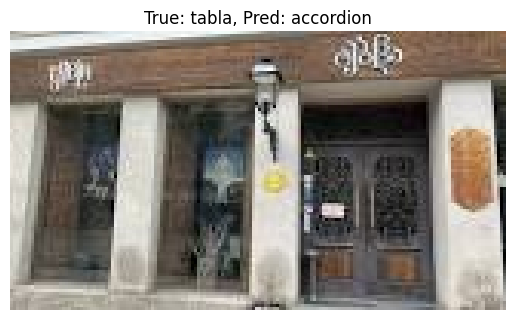

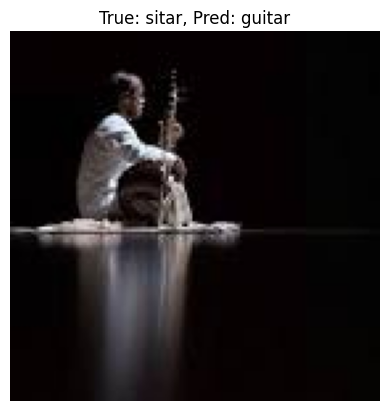

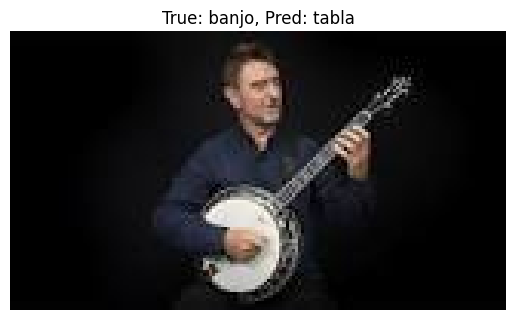

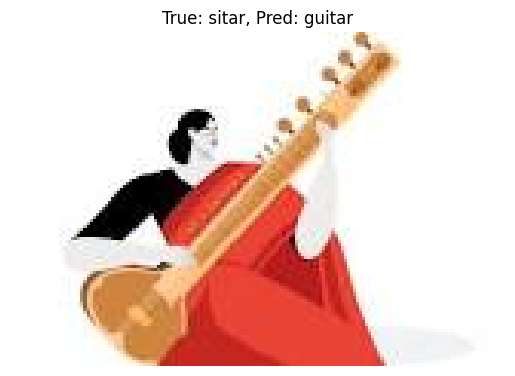

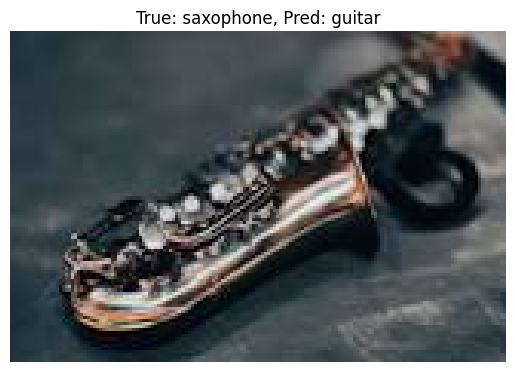

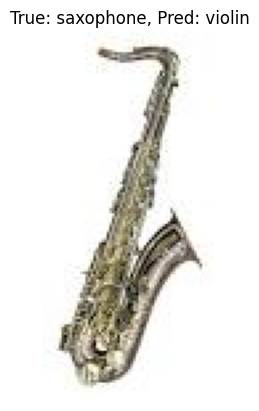

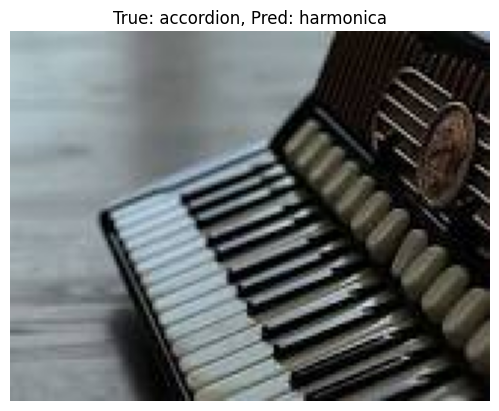

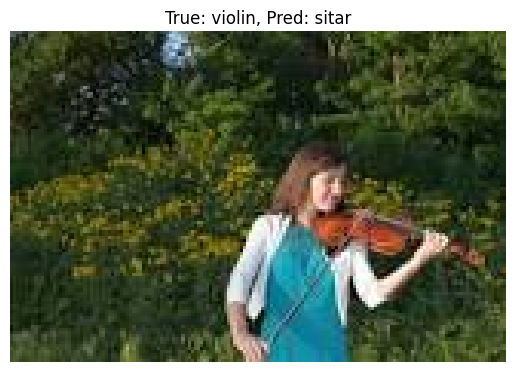

In [20]:
for i in errors:
    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred[i]]
    index = test_idx[i]
    img = orig_dataset[index][0]

    plt.imshow(img)
    plt.axis('off')
    plt.title(f'True: {true_label}, Pred: {pred_label}')
    plt.show()

# Отчет

- Была рассмотрена задача **классификации** "Музыкальных инструментов на фото"
- Дообучена pretrained-модель resnet50, гиперпараметры: `num_epochs = 20; batch_size = 32; lr = 0.001`
- Модель достигла метрики `accuracy(f1) = 0.86`
- Проанализированы ошибки модели на тестовой выборке